In [1]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


2.0.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti


In [17]:
import os
import json
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


In [18]:
class COCODataset(Dataset):
    def __init__(self, img_dir, ann_file):
        self.img_dir = img_dir

        with open(ann_file) as f:
            coco = json.load(f)

        self.images = {img["id"]: img for img in coco["images"]}
        self.annotations = {}
        for ann in coco["annotations"]:
            self.annotations.setdefault(ann["image_id"], []).append(ann)

        self.ids = list(self.images.keys())

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.images[img_id]

        image = Image.open(
            os.path.join(self.img_dir, img_info["file_name"])
        ).convert("RGB")

        boxes = []
        labels = []

        for ann in self.annotations.get(img_id, []):
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"] + 1)  # background = 0

        # 🔴 BELANGRIJKE FIX (lege images!)
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(img_id)
        }

        image = torchvision.transforms.ToTensor()(image)
        return image, target


In [20]:

# ===============================
# 2. DATALOADERS
# ===============================
def collate_fn(batch):
    return tuple(zip(*batch))


DATASET_ROOT = "../dataset/splitted_coco_dataset"

train_ds = COCODataset(
    f"{DATASET_ROOT}/train/images",
    f"{DATASET_ROOT}/train/annotations.json"
)

val_ds = COCODataset(
    f"{DATASET_ROOT}/val/images",
    f"{DATASET_ROOT}/val/annotations.json"
)

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

In [21]:

# ===============================
# 3. MODEL
# ===============================
NUM_CLASSES = 22 + 1  # +1 background

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights="DEFAULT"
)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features, NUM_CLASSES
)

In [22]:
# ===============================
# 4. TRAINING SETUP
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model.to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)


Using device: cuda


In [23]:
# ===============================
# 5. EVALUATIE
# ===============================
def evaluate_coco(model, data_loader, ann_file, device):
    model.eval()
    coco_gt = COCO(ann_file)
    coco_results = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            image_ids = [t["image_id"].item() for t in targets]

            outputs = model(images)

            for output, img_id in zip(outputs, image_ids):
                boxes = output["boxes"].cpu()
                scores = output["scores"].cpu()
                labels = output["labels"].cpu()

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box.tolist()
                    coco_results.append({
                        "image_id": img_id,
                        "category_id": int(label) - 1,
                        "bbox": [x1, y1, x2 - x1, y2 - y1],
                        "score": float(score)
                    })

    coco_dt = coco_gt.loadRes(coco_results)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

In [25]:

# ===============================
# 6. TRAINING LOOP
# ===============================
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} - Loss: {total_loss:.2f}")
    

    # evaluatie na elke epoch
    def evaluate_coco(model, data_loader, ann_file, device):
        model.eval()
        coco_gt = COCO(ann_file)
    
        # 🔴 FIX: voeg ontbrekende COCO-velden toe
        if "info" not in coco_gt.dataset:
            coco_gt.dataset["info"] = {}
        if "licenses" not in coco_gt.dataset:
            coco_gt.dataset["licenses"] = []
    
        coco_results = []


print("\n✔ Training + evaluatie klaar")



Epoch 1/10 - Loss: 351.16

Epoch 2/10 - Loss: 296.23

Epoch 3/10 - Loss: 276.73

Epoch 4/10 - Loss: 270.31

Epoch 5/10 - Loss: 264.00

Epoch 6/10 - Loss: 265.34

Epoch 7/10 - Loss: 263.00

Epoch 8/10 - Loss: 267.76

Epoch 9/10 - Loss: 267.49

Epoch 10/10 - Loss: 265.26

✔ Training + evaluatie klaar


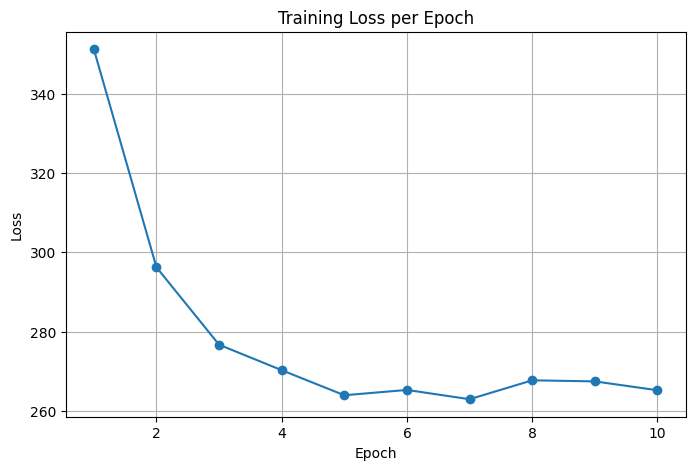

In [26]:
import matplotlib.pyplot as plt

loss_per_epoch = [351.16, 296.23, 276.73, 270.31, 264.00, 265.34, 263.00, 267.76, 267.49, 265.26]

plt.figure(figsize=(8,5))
plt.plot(range(1, len(loss_per_epoch)+1), loss_per_epoch, marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [27]:
MODEL_PATH = "fasterrcnn_model.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to fasterrcnn_model.pth


In [35]:
test_ds = COCODataset(
    f"{DATASET_ROOT}/test/images",
    f"{DATASET_ROOT}/test/annotations.json"
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)


In [36]:
evaluate_coco(
    model,
    test_loader,
    f"{DATASET_ROOT}/test/annotations.json",
    device
)


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


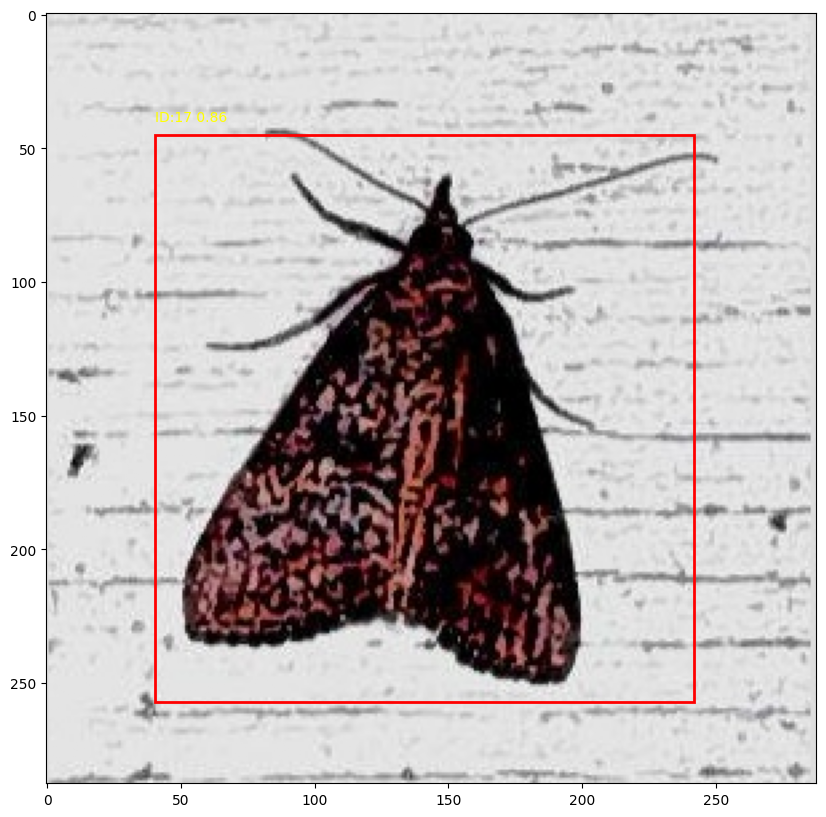

In [37]:
import matplotlib.patches as patches

def visualize_prediction(model, dataset, idx=0, threshold=0.5):
    model.eval()
    img, target = dataset[idx]
    with torch.no_grad():
        pred = model([img.to(device)])[0]

    img_np = img.permute(1,2,0).cpu().numpy()

    fig, ax = plt.subplots(1,1, figsize=(10,10))
    ax.imshow(img_np)

    # teken voorspellingen
    for box, score, label in zip(pred["boxes"], pred["scores"], pred["labels"]):
        if score > threshold:
            x1, y1, x2, y2 = box.cpu().numpy()
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"ID:{label.item()} {score:.2f}", color='yellow', fontsize=10)

    plt.show()

visualize_prediction(model, test_ds, idx=0)
